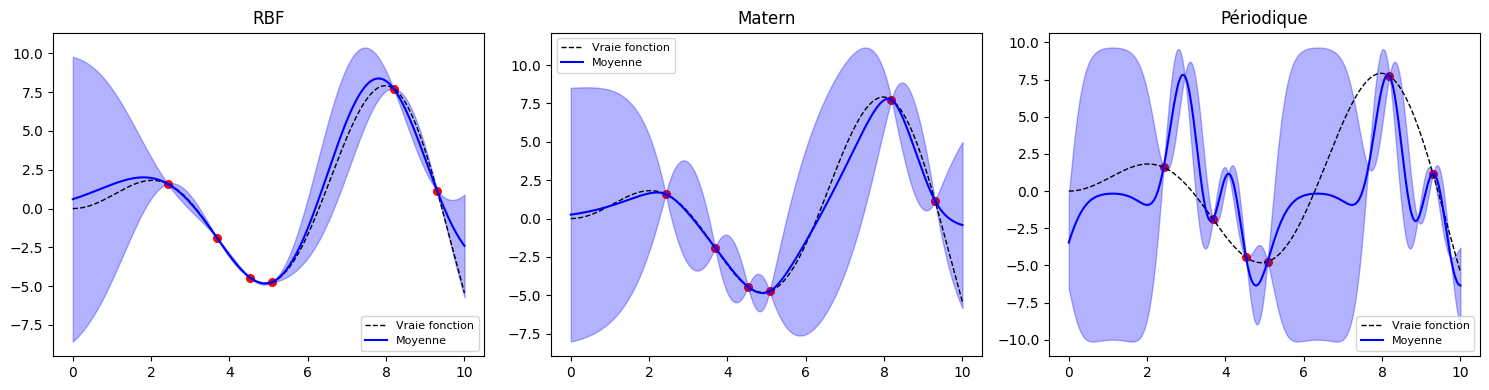

In [ ]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from Kernax import SEMagmaKernel, Matern32Kernel, PeriodicKernel
import numpy as np
import GP

kernels = {
    'SquareExpo': SEMagmaKernel(1.0, 1.0),
    'Matern': Matern32Kernel(1.0),
    'Périodique': PeriodicKernel(1.0, 1.0, 5.0)
}

X = np.linspace(0, 10, 1000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))
rng = np.random.RandomState(1)
#We choose randomly the observations 
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

X_plot = np.linspace(0, 10, 400).reshape(-1,1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, kern) in zip(axes, kernels.items()):
    gp = GP.GP(kern, Alpha=1e-5, NormalizeObs=True).fit(X_train, y_train, num_iters=200)
    mu, std = gp.predict(X_plot, Return_std=True)
    ax.plot(X, y, 'k--', lw=1, label='Real function')
    ax.scatter(X_train, y_train, c='red', s=30)
    ax.plot(X_plot, mu, 'b-', label='Mean')
    ax.fill_between(X_plot.ravel(), mu-1.96*std, mu+1.96*std, alpha=0.3, color='blue')
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

<details>
  <summary>Click to show code </summary>

In [ ]:

length_scales = [0.2, 1.0, 3.0]
plt.figure(figsize=(12,4))
for i, ls in enumerate(length_scales, 1):
    plt.subplot(1,3,i)
    gp = GP.GP(SEMagmaKernel(ls, 1.0), Alpha=1e-5).fit(X_train, y_train, num_iters=200)
    mu, std = gp.predict(X_plot, Return_std=True)
    plt.plot(X, y, 'k--', lw=1)
    plt.scatter(X_train, y_train, c='red', s=30)
    plt.plot(X_plot, mu, 'b-')
    plt.fill_between(X_plot.ravel(), mu-1.96*std, mu+1.96*std, alpha=0.3)
    plt.title(f'ℓ = {ls}')
plt.tight_layout()
plt.show()

</details>

In [ ]:
gp = GP.GP(SEMagmaKernel(1.0, 1.0), Alpha=1e-5).fit(X_train, y_train)
mu, cov = gp.predict(X_plot, Return_cov=True)
L = np.linalg.cholesky(cov + 1e-4*np.eye(len(X_plot)))
samples = mu[:,None] + L @ np.random.randn(len(X_plot), 5)

plt.figure(figsize=(10,5))
plt.plot(X, y, 'k--', label='Real function')
plt.scatter(X_train, y_train, c='red', s=40, label='Observations')
plt.plot(X_plot, samples, lw=0.8, alpha=0.7)
plt.fill_between(X_plot.ravel(), mu-1.96*std, mu+1.96*std, alpha=0.2, color='blue')
plt.legend()
plt.title("5 posterior samples")
plt.show()